In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from transformers import SegformerForSemanticSegmentation
from transformers import SegformerImageProcessor
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import torch
from PIL import Image

c:\Users\zeyad\anaconda3\envs\ml\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### loading images from folders using a custom dataset to fit the trasnformer

In [3]:
train_data_path = "bdd100k_seg/bdd100k/seg/images/train"
val_data_path = "bdd100k_seg/bdd100k/seg/images/val"
test_data_path = "bdd100k_seg/bdd100k/seg/images/test"

train_output_path = "bdd100k_seg/bdd100k/seg/labels/train"
val_output_path = "bdd100k_seg/bdd100k/seg/labels/val"

class CustomDataset(Dataset):
    def __init__(self, images_path, masks_path, image_processor):
        self.images_path = images_path
        self.masks_path = masks_path
        self.image_processor = image_processor
        self.image_files = os.listdir(images_path)
    def __len__(self):
        return len(self.image_files)
    def __getitem__(self, idx):
        image_file = self.image_files[idx]
        image_path = os.path.join(self.images_path, image_file)
        mask_path = os.path.join(self.masks_path, image_file).replace(".jpg", "_train_id.png")
        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path)
        mask = np.array(mask)
        encoded = self.image_processor(images = image, segmentation_maps = mask, return_tensors = "pt")
        for k, v in encoded.items():
            encoded[k] = v.squeeze()
        return encoded

class CustomTestDataset(Dataset):
    def __init__(self, images_path, image_processor):
        self.images_path = images_path
        self.image_processor = image_processor
        self.image_files = os.listdir(images_path)
    def __len__(self):
        return len(self.image_files)
    def __getitem__(self, idx):
        image_file = self.image_files[idx]
        image_path = os.path.join(self.images_path, image_file)
        image = Image.open(image_path).convert("RGB")
        encoded = self.image_processor(images = image, return_tensors = "pt")
        for k, v in encoded.items():
            encoded[k] = v.squeeze()
        return encoded

### loading the segformer B1 model and creating datasets and makeing the model run on GPU

In [4]:
model_name = "nvidia/segformer-b1-finetuned-ade-512-512"
image_processor = SegformerImageProcessor.from_pretrained(model_name)
model = SegformerForSemanticSegmentation.from_pretrained(model_name, num_labels=19, ignore_mismatched_sizes=True)
train_dataset = CustomDataset(train_data_path, train_output_path, image_processor)
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_dataset = CustomDataset(val_data_path, val_output_path, image_processor)
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_dataset = CustomTestDataset(test_data_path, image_processor)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=False)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

[transformers] You passed `num_labels=19` which is incompatible to the `id2label` map of length `150`.
Loading weights: 100%|██████████| 208/208 [00:00<00:00, 17756.92it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b1-finetuned-ade-512-512
Key                           | Status   |                                                                                                      
------------------------------+----------+------------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([19, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([19])                      

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(128, 320, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(320, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)

In [5]:
def compute_ioU(preds, labels, num_classes):
    ious = []
    for cls in range(num_classes):
        pred_inds = (preds == cls)
        label_inds = (labels == cls)
        intersection = (pred_inds & label_inds).sum().item()
        union = (pred_inds | label_inds).sum().item()
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)
    return np.nanmean(ious)

In [ ]:
optimizer = AdamW(model.parameters(), lr=5e-5)
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch in train_dataloader:
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss = outputs.loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    model.eval()
    validation_loss = 0
    with torch.no_grad():
        for batch in val_dataloader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(pixel_values=pixel_values, labels=labels)
            preds = torch.argmax(outputs.logits, dim=1)
            preds = torch.nn.functional.interpolate(preds.unsqueeze(1).float(), size=labels.shape[1:], mode='bilinear').squeeze(1).long()
            iou = compute_ioU(preds, labels, num_classes=19)
            loss = outputs.loss
            validation_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_loss/len(train_dataloader)}")
    print(f"Epoch {epoch+1}/{num_epochs}, Validation Loss: {validation_loss/len(val_dataloader)}")
    print(f"Epoch {epoch+1}/{num_epochs}, Validation IoU: {iou}")
    print("-" * 30)

Epoch 1/100, Training Loss: 0.71273410234281
Epoch 1/100, Validation Loss: 0.37162873977422717
Epoch 1/100, Validation IoU: 0.20528651040995183
------------------------------


In [ ]:
predictions = []
model.eval()
with torch.no_grad():
    for batch in test_dataloader:
        pixel_values = batch["pixel_values"].to(device)
        outputs = model(pixel_values=pixel_values)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        preds = torch.nn.functional.interpolate(torch.from_numpy(preds).unsqueeze(1).float(), size=(720, 1280), mode='bilinear').squeeze(1).long().numpy()
        predictions.append(preds)

In [ ]:
predictions[0].shape

(4, 720, 1280)

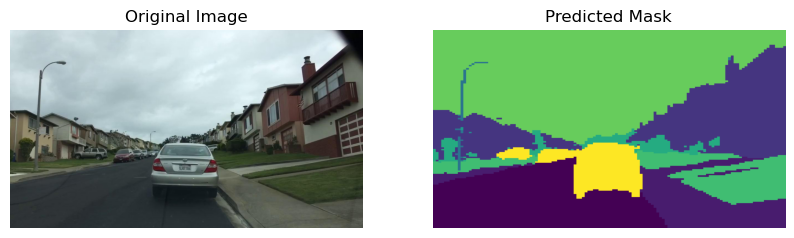

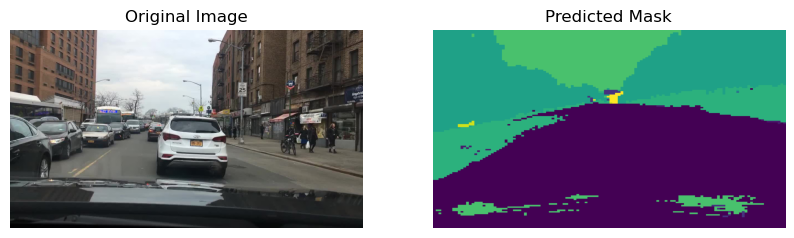

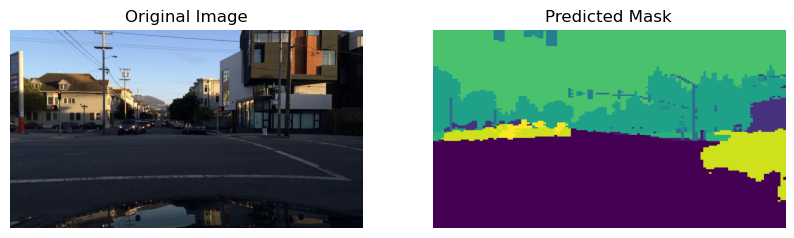

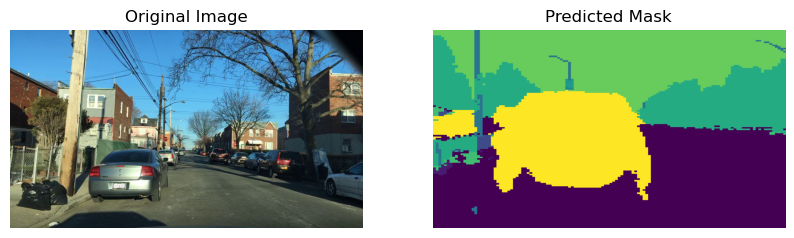

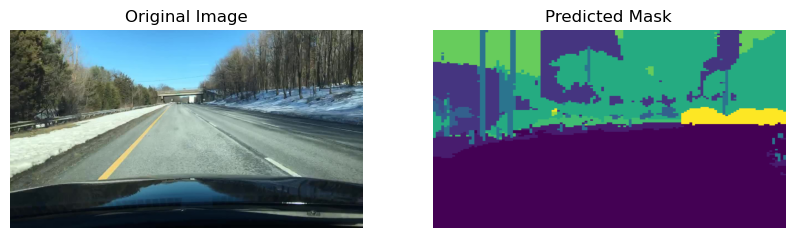

In [ ]:
for i in range(5):
    image_file = test_dataset.image_files[i]
    image_path = os.path.join(test_data_path, image_file)
    image = Image.open(image_path).convert("RGB")
    pred_mask = predictions[i][0]
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(image)
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.title("Predicted Mask")
    plt.imshow(pred_mask)
    plt.axis("off")
    plt.show()